# Experiment 02: Depolarizing Noise Analysis

## Objective

The objective of this experiment is to investigate the effect of depolarizing noise on an entangled Bell State and analyze how increasing noise strength impacts measurement outcomes.

## Theoretical Background

Depolarizing noise is one of the most common quantum noise models.

The quantum state is replaced by a completely mixed state, causing loss of quantum information.

As the depolarizing probability increases:

- Fidelity decreases
- Entanglement degrades
- Measurement distributions become more random

This experiment studies these effects using a Bell State.

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [3]:
from src.circuits import bell_state_circuit
from src.noise_models import create_depolarizing_noise

In [4]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt
import numpy as np

## Ideal Bell State Simulation

In [5]:
qc = bell_state_circuit()

ideal_simulator = AerSimulator()

ideal_result = ideal_simulator.run(
    qc,
    shots=1000
).result()

ideal_counts = ideal_result.get_counts()

ideal_counts

{'00': 510, '11': 490}

## Depolarizing Noise Model

In [6]:
noise_probability = 0.05

noise_model = create_depolarizing_noise(
    noise_probability
)

noise_simulator = AerSimulator(
    noise_model = noise_model
)


In [14]:
noisy_result = noise_simulator.run(
    qc,
    shots=1000
).result()

noisy_counts = noisy_result.get_counts()

noisy_counts

{'00': 482, '11': 487, '01': 15, '10': 16}

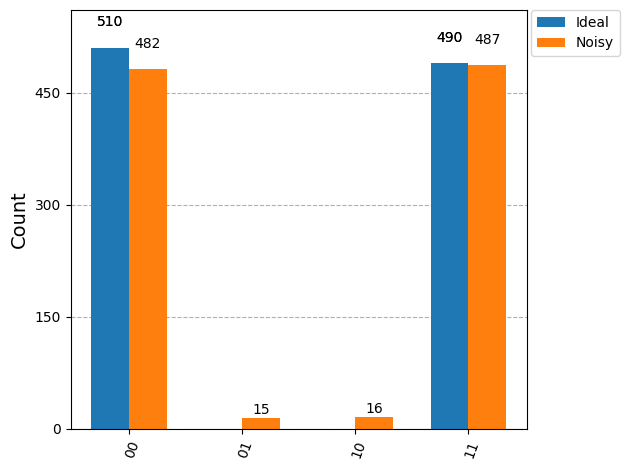

In [15]:
plot_histogram(
    [ideal_counts, noisy_counts],
    legend=["Ideal", "Noisy"]
)

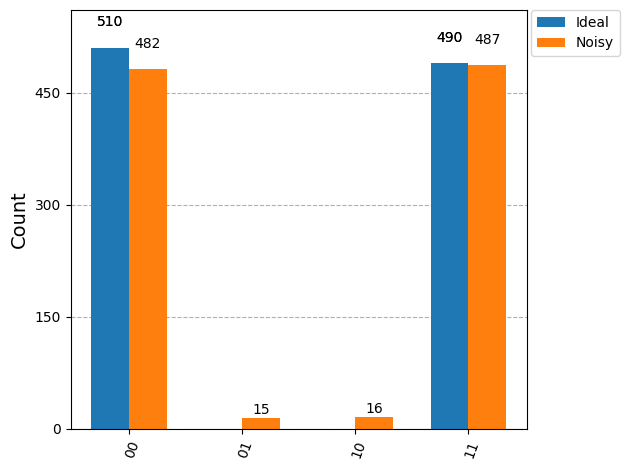

In [16]:
fig = plot_histogram(
    [ideal_counts, noisy_counts],
    legend=["Ideal", "Noisy"]
)

fig.savefig(
    "../results/depolarizing_noise_histogram.png"
)

fig

## Noise swap

In [17]:
probabilities = np.linspace(
    0,
    0.30,
    10
)

success_rates = []

In [18]:
for p in probabilities:
    noise_model = create_depolarizing_noise(p)

    simulator = AerSimulator(
        noise_model = noise_model
    )
    result = simulator.run(
        qc,
        shots = 1000
    ).result()

    counts = result.get_counts()
    success = (
        counts.get("00", 0)
        +
        counts.get("11", 0)
    ) / 1000

    success_rates.append(success)

<function matplotlib.pyplot.show(close=None, block=None)>

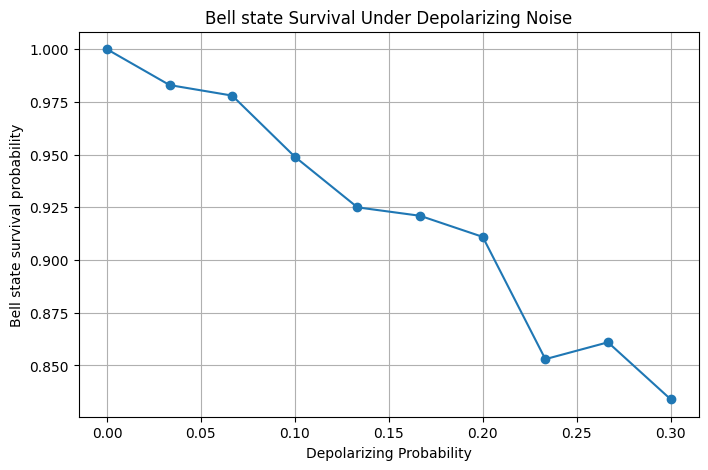

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    probabilities,
    success_rates,
    marker ="o"
)

plt.xlabel("Depolarizing Probability")
plt.ylabel("Bell state survival probability")
plt.title("Bell state Survival Under Depolarizing Noise")

plt.grid(True)

plt.savefig(
    "../results/depolarizing_noise_fidelity.png"
)


plt.show

## Analysis

The Bell state success rate decreases as depolarizing probability increases, demonstrating the destructive effect of depolarizing noise on quantum information. The appearance of erroneous measurement outcomes indicates that noise disrupts the correlations responsible for entanglement. The overall downward trend confirms that increasing noise strength reduces the reliability of quantum computations

## Conclusion

Depolarizing noise significantly impacts the reliability of entangled quantum states.

The experiment shows a clear reduction in Bell State success probability as noise strength increases.

These results motivate the need for error mitigation and quantum error correction techniques in practical quantum computing systems.